<a href="https://colab.research.google.com/github/Brunolms11/Calc_Numerico/blob/main/C%C3%B3pia_de_ativgauss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instala o imageio caso ainda não esteja instalado no ambiente
!pip install -q imageio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
from IPython.display import Image, display

Função de animação configurada!
GIF 'eliminacao_gauss.gif' gerado com sucesso!
Exibindo a animação abaixo:


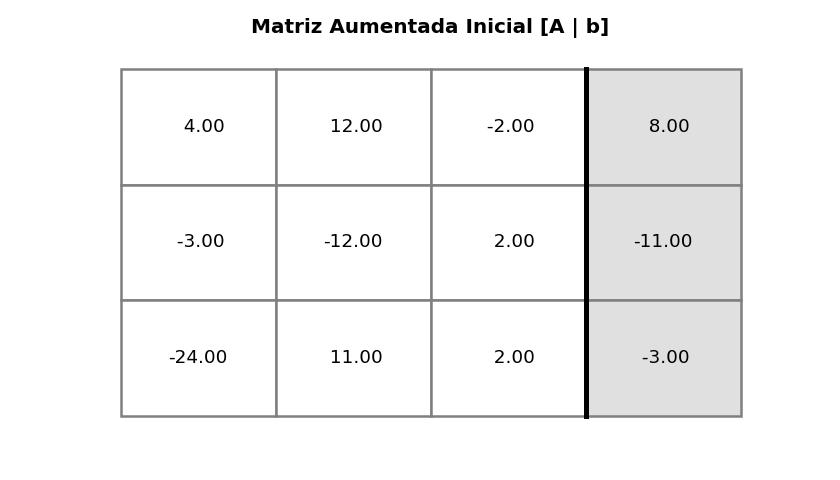

In [ ]:
def eliminacao_gauss_animada(A, b):
    """
    Executa a eliminação de Gauss com pivoteamento parcial e gera quadros (frames)
    ilustrando visualmente cada etapa do processo.
    """
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = len(b)
    M = np.column_stack([A, b]) # Matriz aumentada [A | b]

    frames = []

    def criar_frame(M_curr, destaque_linha=None, destaque_pivo=None, mensagem=""):
        """Gera uma figura estilizada para representar a matriz aumentada atual."""
        fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
        ax.axis('off')

        rows, cols = M_curr.shape

        # Desenhar células e valores
        for i in range(rows):
            for j in range(cols):
                val = M_curr[i, j]
                text_str = f"{val:6.2f}"

                # Definir cores de destaque
                bg_color = "white"
                text_color = "black"
                weight = "normal"

                if destaque_pivo == (i, j):
                    bg_color = "#4CAF50" # Verde para o pivô
                    text_color = "white"
                    weight = "bold"
                elif destaque_linha and i in destaque_linha:
                    bg_color = "#FFC107" if j < n else "#FF9800" # Amarelo/Laranja para linhas envolvidas
                elif j == n:
                    bg_color = "#E0E0E0" # Cinza claro para o vetor b

                rect = plt.Rectangle((j, rows - 1 - i), 1, 1, facecolor=bg_color, edgecolor='gray', lw=1.5)
                ax.add_patch(rect)

                ax.text(j + 0.5, rows - 1 - i + 0.5, text_str,
                        ha='center', va='center', fontsize=11, fontweight=weight, color=text_color)

        # Linha vertical separando A e b
        ax.plot([n, n], [0, rows], color='black', linewidth=3)

        ax.set_xlim(-0.1, cols + 0.1)
        ax.set_ylim(-0.1, rows + 0.1)
        plt.title(mensagem, fontsize=12, fontweight='bold', pad=15)

        # Converter figura em matriz para imagem (corrigido)
        fig.canvas.draw()
        rgba = np.asarray(fig.canvas.buffer_rgba())
        frame = rgba[:, :, :3]
        plt.close(fig)
        return frame

    # Estado Inicial
    frames.append(criar_frame(M, mensagem="Matriz Aumentada Inicial [A | b]"))

    for k in range(n - 1):
        # 1. Escolha do Pivô (Pivoteamento Parcial)
        p = k + np.argmax(np.abs(M[k:, k]))

        frames.append(criar_frame(M, destaque_pivo=(p, k),
                                  mensagem=f"Passo {k+1}: Procurando maior pivô na coluna {k+1} (Pivô = {M[p, k]:.2f})"))

        # 2. Troca de Linhas se necessário
        if p != k:
            M[[k, p], :] = M[[p, k], :]
            frames.append(criar_frame(M, destaque_linha=[k, p],
                                      mensagem=f"Troca de linhas: L{k+1} <-> L{p+1}"))

        # 3. Eliminação dos elementos abaixo do pivô
        for i in range(k + 1, n):
            fator = M[i, k] / M[k, k]
            M[i, k:] -= fator * M[k, k:]
            frames.append(criar_frame(M, destaque_pivo=(k, k), destaque_linha=[i],
                                      mensagem=f"Eliminação na L{i+1}: L{i+1} = L{i+1} - ({fator:.2f}) * L{k+1}"))

    # Estado Final Triangular Superior
    frames.append(criar_frame(M, mensagem="Forma Triangular Superior Concluída!"))
    return M, frames


# Definindo o sistema linear
A = np.array([[4., 12., -2.],
              [-3., -12., 2.],
              [-24., 11., 2.]])

b = np.array([8., -11., -3.])

# Executar a eliminação e capturar frames
M_final, frames = eliminacao_gauss_animada(A, b)

# Salvar como arquivo GIF
nome_gif = "eliminacao_gauss.gif"
imageio.mimsave(nome_gif, frames, fps=0.33, loop=0)

print(f"GIF '{nome_gif}' gerado com sucesso!\nExibindo a animação abaixo:")

# Exibir no Google Colab
display(Image(filename=nome_gif))

Dependências carregadas com sucesso!
Função 3D configurada!
GIF 'animacao_planos_gauss.gif' gerado com sucesso!


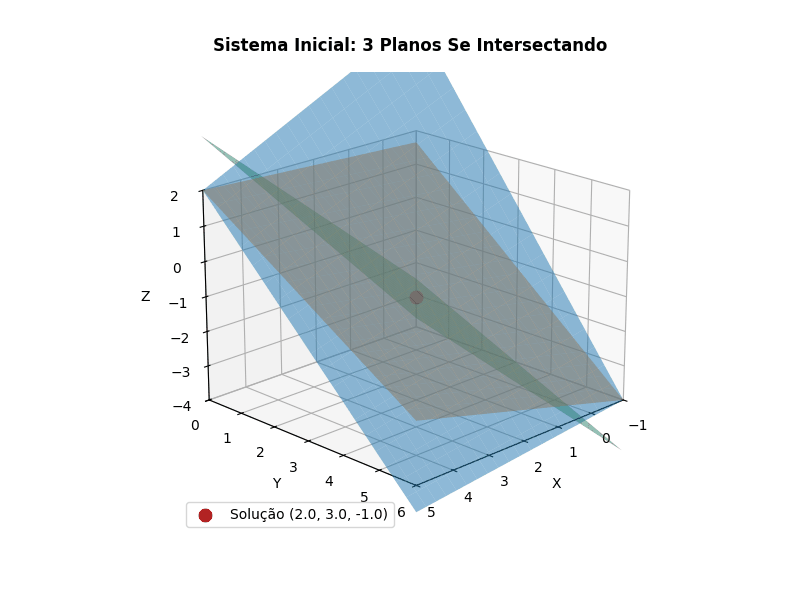

In [ ]:
# Instalação de dependências
!pip install -q imageio matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio
from IPython.display import Image, display



def animar_planos_gauss(A, b):
    """
    Gera uma animação 3D da transformação dos planos durante
    a eliminação de Gauss com pivoteamento parcial.
    """
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = len(b)

    # Solução do sistema (ponto fixo de interseção)
    x_sol = np.linalg.solve(A, b)

    # Malha para desenhar os planos
    x_range = np.linspace(x_sol[0] - 3, x_sol[0] + 3, 20)
    y_range = np.linspace(x_sol[1] - 3, x_sol[1] + 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    cores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Cores para as equações/planos
    frames = []

    def gerar_frame_3d(A_curr, b_curr, titulo):
        fig = plt.figure(figsize=(8, 6), dpi=100)
        ax = fig.add_subplot(111, projection='3d')

        # Plota cada equação como um plano a*x + b*y + c*z = d => z = (d - a*x - b*y) / c
        for i in range(n):
            a, b_coef, c = A_curr[i]
            d = b_curr[i]

            if abs(c) > 1e-5:
                Z = (d - a * X - b_coef * Y) / c
                ax.plot_surface(X, Y, Z, alpha=0.5, color=cores[i], edgecolor='none')
            else:
                # Caso o plano seja vertical (c próximo de 0)
                z_range = np.linspace(x_sol[2] - 3, x_sol[2] + 3, 20)
                X_v, Z_v = np.meshgrid(x_range, z_range)
                if abs(b_coef) > 1e-5:
                    Y_v = (d - a * X_v) / b_coef
                    ax.plot_surface(X_v, Y_v, Z_v, alpha=0.5, color=cores[i], edgecolor='none')

        # Plota o ponto de interseção (Solução)
        ax.scatter(x_sol[0], x_sol[1], x_sol[2], color='red', s=80, label=f'Solução ({x_sol[0]:.1f}, {x_sol[1]:.1f}, {x_sol[2]:.1f})')

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titulo, pad=15, fontweight='bold')
        ax.legend()

        # Ajusta limites de visualização
        ax.set_xlim(x_sol[0] - 3, x_sol[0] + 3)
        ax.set_ylim(x_sol[1] - 3, x_sol[1] + 3)
        ax.set_zlim(x_sol[2] - 3, x_sol[2] + 3)
        ax.view_init(elev=20, azim=45)

        # Captura do buffer de imagem compatível com versões recentes do Matplotlib
        fig.canvas.draw()
        rgba_buffer = fig.canvas.buffer_rgba()
        frame = np.asarray(rgba_buffer)[:, :, :3] # Converter RGBA para RGB
        plt.close(fig)
        return frame

    # Estado Inicial
    frames.append(gerar_frame_3d(A, b, "Sistema Inicial: 3 Planos Se Intersectando"))

    # Processo de Eliminação
    for k in range(n - 1):
        # Pivoteamento
        p = k + np.argmax(np.abs(A[k:, k]))
        if p != k:
            A[[k, p]] = A[[p, k]]
            b[[k, p]] = b[[p, k]]
            frames.append(gerar_frame_3d(A, b, f"Troca de Linhas: L{k+1} <-> L{p+1}"))

        # Eliminação
        for i in range(k + 1, n):
            fator = A[i, k] / A[k, k]
            A[i] -= fator * A[k]
            b[i] -= fator * b[k]
            frames.append(gerar_frame_3d(A, b, f"Operação na Linha L{i+1}: Zerando termo abaixo do pivô"))

    # Estado Final
    frames.append(gerar_frame_3d(A, b, "Forma Triangular: Planos Simplificados!"))
    return frames

print("Função 3D configurada!")

# Sistema Linear do PDF:
# 2x + y - z = 8
# -3x - y + 2z = -11
# -2x + y + 2z = -3

A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])

b = np.array([8., -11., -3.])

# Gerar frames
frames_3d = animar_planos_gauss(A, b)

nome_gif_planos = "animacao_planos_gauss.gif"

# fps=0.5 faz com que cada imagem fique visível por 2 segundos (transição bem mais lenta)
imageio.mimsave(nome_gif_planos, frames_3d, fps=0.5, loop=0)

print(f"GIF '{nome_gif_planos}' gerado com sucesso!")
display(Image(filename=nome_gif_planos))